### Lab 5 — Classification

In our previous lab, we used regression to predict continuous numbers (insurance costs). Today, we move to **Classification**: predicting which category (or class) a piece of data belongs to.

We will use the **Breast Cancer Wisconsin Dataset**. Our goal is to build a model that can look at tumor measurements (like radius, texture, and smoothness) and classify whether the tumor is **Malignant** (cancerous) or **Benign** (non-cancerous).

### 1. Loading and Inspecting the Data

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("data/breast_cancer.csv")

In [3]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [7]:
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
df["diagnosis"].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

In [9]:
df["diagnosis"] = df["diagnosis"].map({'B': 0, 'M': 1})
df["diagnosis"].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

This is only mildly imbalanced, so forcing a 50/50 dataset might
- Throw away useful data (if you undersample the 357 class)
- Introduce artificial patterns (if you oversample duplicates)
- Make your model less representative of real-world data

If your classes are moderately or highly imbalanced (90/10), then balancing can help.
- The model won’t just learn to predict the majority class.
- Improves performance on the minority class (often the one you care about)

Useful for fraud detection, medical diagnosis, rare event prediction

In these cases, using equal samples (via undersampling or oversampling) can be beneficial.

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    int64  
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

In [11]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [12]:
df.describe()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,0.372583,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,0.483918,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,0.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,0.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,0.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,1.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,1.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


---
### 2. Preprocessing: Scaling the Features

Unlike our previous insurance dataset, all 30 features here are already numerical measurements, so we don't need to encode any categorical variables like 'region' or 'smoker'.

However, we **must scale our data**. Tumor area might be measured in the hundreds (e.g., 500 $mm^2$), while smoothness is measured in tiny decimals (e.g., 0.09). If we don't scale, our model might unfairly prioritize the feature with the larger numbers. We will use `StandardScaler` to give every feature a mean of 0 and a standard deviation of 1.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

In [14]:
X

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


In [15]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [17]:
# stratify ensures class balance in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

# Fit on training data, transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

You have:
- Class A: 357 samples
- Class B: 212 samples
- Total: 569 samples

### Step 1: Compute Proportions
- Class A → 357 / 569 ≈ 62.8%
- Class B → 212 / 569 ≈ 37.2%

### Step 2: Apply `test_size = 0.2`
- Test set size ≈ 569 * 0.2 ≈ 114 samples
- Train set size ≈ 455 samples

### Step 3: Stratified Split
`stratify = y` keeps the same ~63/37 ratio in both splits.

#### Test Set (~114 samples)
- Class A → 114 * 0.628 ≈ 72
- Class B → 114 * 0.372 ≈ 42

#### Train Set (~455 samples)
- Class A → 455 * 0.628 ≈ 285
- Class B → 455 * 0.372 ≈ 170

---
### 3. Logistic Regression

**How it connects to Linear Regression:**
Under the hood, Logistic Regression actually calculates the exact same linear equation you are used to:
$$z = \beta_0 + \beta_1x_1 + \beta_2x_2 + \dots$$

**The Sigmoid Function:**
The problem is that $z$ could be any number from $-\infty$ to $+\infty$. To fix this, Logistic Regression wraps that linear equation in a mathematical wrapper called the **Sigmoid Function**. This function takes any number and squishes it into a probability strictly between 0 and 1.
$$Probability = \frac{1}{1 + e^{-z}}$$

**The Threshold:**
Once the model calculates a probability (e.g., 0.85), it needs to make a final decision. By default, the model uses a **threshold of 0.5**:
* If Probability $\ge$ 0.5 $\rightarrow$ Predict Class 1 (Malignant)
* If Probability $<$ 0.5 $\rightarrow$ Predict Class 0 (Benign)

In [18]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = log_reg.predict(X_test_scaled) # this gives hard labels like 0 or 1, threshold of 0.5

In [19]:
y_pred

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1])

In [24]:
# If we want to see the raw probabilities before the 0.5 threshold is applied:
y_probabilities = log_reg.predict_proba(X_test_scaled)
y_probabilities_class1 = log_reg.predict_proba(X_test_scaled)[:, 1] # Get probabilities for class 1

In [25]:
y_probabilities

array([[9.99635432e-01, 3.64568116e-04],
       [1.07465986e-08, 9.99999989e-01],
       [9.57432053e-01, 4.25679471e-02],
       [4.23812678e-01, 5.76187322e-01],
       [4.90844511e-01, 5.09155489e-01],
       [9.99383998e-01, 6.16001620e-04],
       [2.38465914e-01, 7.61534086e-01],
       [9.98987828e-01, 1.01217174e-03],
       [9.99431274e-01, 5.68725516e-04],
       [9.89232420e-01, 1.07675795e-02],
       [6.90940474e-02, 9.30905953e-01],
       [9.99927168e-01, 7.28319772e-05],
       [1.00901925e-07, 9.99999899e-01],
       [9.95605507e-01, 4.39449272e-03],
       [9.92247374e-01, 7.75262630e-03],
       [9.99998294e-01, 1.70641370e-06],
       [9.38570567e-01, 6.14294329e-02],
       [9.99637188e-01, 3.62811536e-04],
       [7.78237987e-01, 2.21762013e-01],
       [9.99949272e-01, 5.07279789e-05],
       [9.98733772e-01, 1.26622816e-03],
       [9.95696579e-01, 4.30342121e-03],
       [4.19456022e-07, 9.99999581e-01],
       [1.67847563e-03, 9.98321524e-01],
       [2.423930

In [26]:
y_probabilities_class1

array([3.64568116e-04, 9.99999989e-01, 4.25679471e-02, 5.76187322e-01,
       5.09155489e-01, 6.16001620e-04, 7.61534086e-01, 1.01217174e-03,
       5.68725516e-04, 1.07675795e-02, 9.30905953e-01, 7.28319772e-05,
       9.99999899e-01, 4.39449272e-03, 7.75262630e-03, 1.70641370e-06,
       6.14294329e-02, 3.62811536e-04, 2.21762013e-01, 5.07279789e-05,
       1.26622816e-03, 4.30342121e-03, 9.99999581e-01, 9.98321524e-01,
       7.57606906e-01, 2.05880632e-04, 1.68680282e-04, 9.69171419e-01,
       9.96639529e-01, 9.99579644e-01, 9.99991854e-01, 2.37027672e-03,
       9.99964222e-01, 9.99954679e-01, 2.66371788e-04, 1.39030746e-02,
       2.02020415e-03, 3.20211147e-06, 9.90930715e-01, 9.31932725e-02,
       1.25745605e-04, 3.52528144e-04, 8.52325081e-01, 2.51409506e-03,
       1.08172442e-02, 9.54067888e-01, 7.56926419e-02, 9.98508631e-01,
       5.69898683e-05, 1.11541174e-03, 9.99999992e-01, 9.98457814e-01,
       7.12763094e-03, 1.05057651e-03, 1.21417298e-04, 9.88025845e-01,
      

In [28]:
threshold = 0.3  # example: lower threshold
y_pred_custom = (y_probabilities_class1 >= threshold).astype(int)

In [29]:
y_pred_custom

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 1, 1])

---
### 4. Evaluating Classification: The Confusion Matrix

In regression, we used metrics like Mean Absolute Error (MAE) because our predictions could be "close." In classification, a prediction is either right or wrong. To see exactly *how* our model is getting things right or wrong, we use a **Confusion Matrix**.

It divides our predictions into four quadrants:
1. **True Positives (TP):** Model predicted Malignant, and it *was* Malignant.
2. **True Negatives (TN):** Model predicted Benign, and it *was* Benign.
3. **False Positives (FP):** Model predicted Malignant, but it was Benign (False Alarm).
4. **False Negatives (FN):** Model predicted Benign, but it was Malignant (Missed Diagnosis).

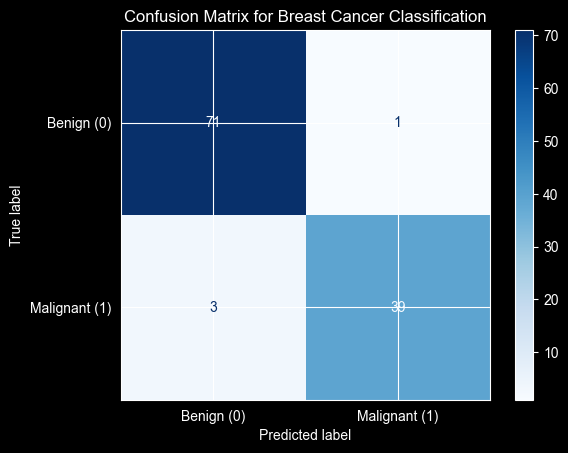

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize it
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign (0)', 'Malignant (1)'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix for Breast Cancer Classification")
plt.show()

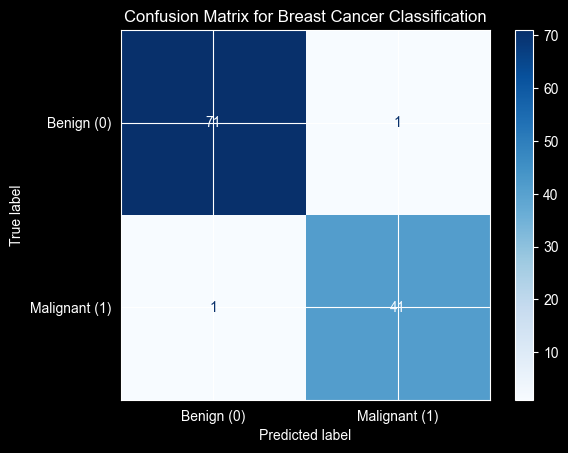

In [30]:
cm2 = confusion_matrix(y_test, y_pred_custom)

# Visualize it
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Benign (0)', 'Malignant (1)'])
disp2.plot(cmap='Blues')
plt.title("Confusion Matrix for Breast Cancer Classification")
plt.show()

---
### 5. Beyond Accuracy: Precision, Recall, and F1-Score

If 99% of patients are healthy and 1% have cancer, a model that just guesses "Healthy" for everyone is 99% accurate—but completely useless. To get a better picture, we rely on three key metrics:

* **Precision (Quality):** Out of all the tumors the model flagged as Malignant, how many were actually Malignant?
  *(Formula: TP / (TP + FP))*
* **Recall / Sensitivity (Quantity):** Out of all the actual Malignant tumors in the dataset, how many did the model successfully find?
  *(Formula: TP / (TP + FN))*
* **F1-Score:** The harmonic mean of Precision and Recall. It provides a single score that balances the two.

In cancer detection, which mistake is worse? A False Positive (unnecessary stress/biopsy) or a False Negative (sending a sick patient home)?

Because False Negatives are highly dangerous, medical models prioritize having a very high **Recall**.

In [31]:
from sklearn.metrics import classification_report

# The classification report generates all these metrics for both classes automatically
report = classification_report(y_test, y_pred, target_names=['Benign (0)', 'Malignant (1)'])
print(report)

               precision    recall  f1-score   support

   Benign (0)       0.96      0.99      0.97        72
Malignant (1)       0.97      0.93      0.95        42

     accuracy                           0.96       114
    macro avg       0.97      0.96      0.96       114
 weighted avg       0.97      0.96      0.96       114



In [33]:
report2 = classification_report(y_test, y_pred_custom, target_names=['Benign (0)', 'Malignant (1)'])
print(report2)

               precision    recall  f1-score   support

   Benign (0)       0.99      0.99      0.99        72
Malignant (1)       0.98      0.98      0.98        42

     accuracy                           0.98       114
    macro avg       0.98      0.98      0.98       114
 weighted avg       0.98      0.98      0.98       114



---
### 6. The ROC Curve and AUC

Earlier, we mentioned that Logistic Regression uses a default threshold of 0.5. But what if we lowered the threshold to 0.2? The model would predict "Malignant" much more easily. We would catch more cancers (higher Recall), but we would also trigger more false alarms (lower Precision).

The **ROC Curve** (Receiver Operating Characteristic) plots this trade-off. It shows the True Positive Rate against the False Positive Rate at *every possible threshold*.

* **The Curve:** A perfect model shoots straight up to the top left corner. A useless model (random guessing) follows the diagonal dashed line.
* **AUC (Area Under the Curve):** A single metric summarizing the ROC curve. An AUC of 1.0 is perfect, 0.5 is random guessing.

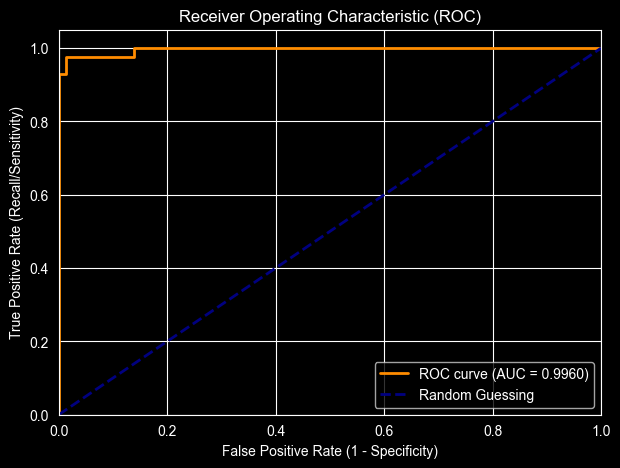

In [35]:
from sklearn.metrics import roc_curve, auc

# Calculate False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_probabilities_class1)

# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [19]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Note: We scale the ENTIRE dataset temporarily just for CV demonstration.
# (In production pipelines, CV and scaling should be chained together in a Pipeline).
X_all_scaled = scaler.fit_transform(X)

# Run 5-fold cross validation, scoring by F1 (for class 1: Malignant)
cv_scores = cross_val_score(log_reg, X_all_scaled, y, cv=5, scoring='f1')

print("--- 5-Fold Cross-Validation (F1-Score) ---")
print(f"Individual Fold F1 Scores : {np.round(cv_scores, 4)}")
print(f"Mean F1 Score             : {cv_scores.mean():.4f}")
print(f"Score Standard Deviation  : {cv_scores.std():.4f}")

--- 5-Fold Cross-Validation (F1-Score) ---
Individual Fold F1 Scores : [0.9767 0.9762 0.963  0.9639 0.9882]
Mean F1 Score             : 0.9736
Score Standard Deviation  : 0.0094


---
## Multi-Class Classification

Now let's look at **Multi-Class Classification**. In this scenario, we have more than two possible categories, but every data point belongs to **exactly one** category.

**The Scenario:**
Imagine we are classifying different species of animals based on 10 physical measurements (features). There are 10 possible species (Classes 0 through 9). An animal can be a Cat (Class 2) or a Dog (Class 5), but it cannot be both at the same time.

In [39]:
from sklearn.datasets import make_classification
import pandas as pd

# Generate a synthetic multi-class dataset
# n_classes=10 (10 different species)
# n_informative=8 (8 features actually contain useful patterns)
X_mc, y_mc = make_classification(
    n_samples=1000,
    n_features=10,
    n_informative=8,
    n_classes=10,
    random_state=42
)

# Convert to DataFrames for easy viewing
X_mc_df = pd.DataFrame(X_mc, columns=[f'Measurement_{i}' for i in range(1, 11)])
y_mc_df = pd.DataFrame(y_mc, columns=['Species_Class'])

print("Feature Data (First 5 rows):")
print(X_mc_df.head())
print("\nTarget Label (First 5 rows - notice it is a single column!):")
print(y_mc_df.head())

Feature Data (First 5 rows):
   Measurement_1  Measurement_2  Measurement_3  Measurement_4  Measurement_5  \
0       0.346786      -3.923491       0.728470      -1.462472       4.320054   
1       0.381022       1.612522       1.300338       1.341591       1.563274   
2      -0.922759      -0.444529       0.435317       0.846344       0.304180   
3      -1.977452       5.242237      -2.505060      -2.406151      -0.511105   
4      -0.228206       0.229281      -0.612596       1.241944      -0.210392   

   Measurement_6  Measurement_7  Measurement_8  Measurement_9  Measurement_10  
0       2.775725      -4.569202      -2.477187       3.539033       -1.773327  
1      -0.054929      -3.289163       2.133359       0.173105       -1.539190  
2       0.001388      -3.238384      -1.809586       1.081909       -1.559169  
3       2.942142       4.233412       1.303567      -2.383420       -0.980247  
4      -0.169376      -0.345595      -0.933253      -0.435602       -0.693191  

Target La

### The Strategy: Native Support (Softmax / Multinomial)

Almost all `scikit-learn` classifiers, including `LogisticRegression`, handle multi-class problems natively out of the box!

Under the hood, `LogisticRegression` usually handles this by upgrading its math to a **Multinomial (Softmax) distribution**. Instead of calculating one probability and checking if it is above 0.5, the model calculates 10 different probabilities (one for each class) that all sum up to 1.0 (100%). It then simply predicts whichever class has the highest probability.

In [40]:
# 1. Split the data
X_mc_train, X_mc_test, y_mc_train, y_mc_test = train_test_split(
    X_mc, y_mc, test_size=0.2, random_state=42
)

# 2. Initialize the model
# max_iter=1000 sets the maximum number of iterations the optimization algorithm is allowed to run while training the model.
mc_model = LogisticRegression(max_iter=1000)

# 3. Fit the model
mc_model.fit(X_mc_train, y_mc_train)

# 4. Make predictions
y_mc_pred = mc_model.predict(X_mc_test)

# Let's peek at the probabilities for the very first test instance
first_instance_probs = mc_model.predict_proba(X_mc_test)[0]

print("--- How Multi-Class Prediction Works ---")
print("Probabilities for all 10 classes for the first animal:")
for i, prob in enumerate(first_instance_probs):
    print(f"Class {i}: {prob*100:.2f}%")

print(f"\nWinning Class (Highest Probability): Class {y_mc_pred[0]}")
print(f"Actual True Class                  : Class {y_mc_test[0]}")

--- How Multi-Class Prediction Works ---
Probabilities for all 10 classes for the first animal:
Class 0: 0.11%
Class 1: 1.21%
Class 2: 17.03%
Class 3: 0.25%
Class 4: 5.89%
Class 5: 2.76%
Class 6: 0.36%
Class 7: 46.88%
Class 8: 24.82%
Class 9: 0.68%

Winning Class (Highest Probability): Class 7
Actual True Class                  : Class 2


### Evaluating Multi-Class Models

Because there is only one correct answer per row, standard **Accuracy** works perfectly here!

However, looking at the **Classification Report** is even more important for multi-class problems. It will break down the Precision, Recall, and F1-Score for every single one of the 10 classes.

In [41]:
from sklearn.metrics import accuracy_score, classification_report

# Calculate overall accuracy
mc_accuracy = accuracy_score(y_mc_test, y_mc_pred)

print(f"Overall Accuracy: {mc_accuracy:.4f} ({(mc_accuracy*100):.2f}%)\n")

# Generate the detailed classification report
print("--- Detailed Classification Report ---")
print(classification_report(y_mc_test, y_mc_pred))

Overall Accuracy: 0.3750 (37.50%)

--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.47      0.83      0.60        18
           1       0.67      0.28      0.39        29
           2       0.14      0.09      0.11        22
           3       0.50      0.57      0.53        21
           4       0.00      0.00      0.00        22
           5       0.25      0.14      0.18        21
           6       0.26      0.35      0.30        17
           7       0.41      0.61      0.49        18
           8       0.33      0.56      0.42        16
           9       0.38      0.56      0.45        16

    accuracy                           0.38       200
   macro avg       0.34      0.40      0.35       200
weighted avg       0.35      0.38      0.34       200



---
## Multi-Label Classification

So far, we have performed **Binary Classification** (predicting exactly one of two classes: Benign OR Malignant).

What if we have more than two classes?
1. **Multi-Class Classification:** The target has $N$ possible classes, but each data point belongs to **exactly one**. (e.g., Is this animal a Cat, a Dog, OR a Bird?)
2. **Multi-Label Classification:** The target has $N$ possible classes, and a data point can belong to **zero, one, or multiple** classes simultaneously. (e.g., Is this movie Action, Comedy, AND/OR Sci-Fi?)

**The Scenario:**
Imagine we are analyzing text documents (like news articles). We have 5 numerical features extracted from the text, and we want to predict which of 3 topics the article covers: `Technology`, `Politics`, and `Finance`. An article could be just about Technology, or it could be about Technology AND Finance.

In [42]:
from sklearn.datasets import make_multilabel_classification
import pandas as pd

# Generate a synthetic multi-label dataset
# n_classes=3 (Technology, Politics, Finance)
# n_labels=1.5 (On average, each article has 1.5 tags)
X_multi, y_multi = make_multilabel_classification(
    n_samples=1000,
    n_features=5,
    n_classes=3,
    n_labels=2,
    random_state=42
)

# Convert to DataFrames for easy viewing
X_m_df = pd.DataFrame(X_multi, columns=[f'Feature_{i}' for i in range(1, 6)])
y_m_df = pd.DataFrame(y_multi, columns=['Technology', 'Politics', 'Finance'])

print("Feature Data (First 5 rows):")
print(X_m_df.head())
print("\nTarget Labels (First 5 rows):")
print(y_m_df.head())

Feature Data (First 5 rows):
   Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
0        6.0       22.0        1.0        3.0        9.0
1        8.0        4.0       16.0       10.0        5.0
2        5.0       27.0       14.0        4.0       10.0
3        7.0       19.0       11.0       10.0       14.0
4        6.0       18.0       13.0        6.0       12.0

Target Labels (First 5 rows):
   Technology  Politics  Finance
0           0         1        0
1           1         0        1
2           0         1        1
3           1         1        1
4           0         1        1


### The Strategy: MultiOutputClassifier

Standard `LogisticRegression` cannot output multiple independent predictions at the same time. To solve this, `scikit-learn` provides the `MultiOutputClassifier`.

It is a clever wrapper: if you have 3 labels to predict, it automatically creates 3 separate Logistic Regression models behind the scenes, trains them all, and combines their predictions into a single output array.

In [43]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# 1. Split the data
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

# 2. Initialize the base model AND the wrapper
base_model = LogisticRegression()
multi_label_model = MultiOutputClassifier(base_model)

# 3. Fit the model (This trains 3 separate Logistic Regressions!)
multi_label_model.fit(X_m_train, y_m_train)

# 4. Make predictions
y_m_pred = multi_label_model.predict(X_m_test)

print(f"Shape of predictions: {y_m_pred.shape}")
print(f"Prediction for the first test instance:\n{y_m_pred[0]}")
print(f"Actual tags for the first test instance:\n{y_m_test[0]}")

Shape of predictions: (200, 3)
Prediction for the first test instance:
[0 1 1]
Actual tags for the first test instance:
[1 1 1]


### Evaluating Multi-Label Models: Hamming Loss

Standard accuracy can be overly harsh in multi-label classification. If an article is about `[Technology, Finance]` and your model predicts `[Technology, Politics]`, standard exact-match accuracy scores that as a `0` (a complete failure), even though the model got the `Technology` part right!

Instead, we often use **Hamming Loss**. It calculates the fraction of individual labels that were incorrectly predicted.
* **Hamming Loss of 0.0:** Perfect predictions.
* **Hamming Loss of 0.10:** The model gets the individual tags wrong about 10% of the time.

In [44]:
from sklearn.metrics import accuracy_score, hamming_loss

# Exact Match Accuracy (Very strict: must get ALL tags correct for a single instance)
exact_match_acc = accuracy_score(y_m_test, y_m_pred)

# Hamming Loss (More forgiving: fraction of individual tags predicted incorrectly)
h_loss = hamming_loss(y_m_test, y_m_pred)

print("--- Multi-Label Evaluation ---")
print(f"Exact Match Accuracy : {exact_match_acc:.4f} ({(exact_match_acc*100):.2f}%)")
print(f"Hamming Loss         : {h_loss:.4f} ({(h_loss*100):.2f}% of tags were wrong)")

--- Multi-Label Evaluation ---
Exact Match Accuracy : 0.6300 (63.00%)
Hamming Loss         : 0.1633 (16.33% of tags were wrong)
